In [ ]:
import sys
import os
from neuron import h, gui

# Load mechanisms
h.nrn_load_dll("/Users/sandek/Desktop/187610master/arm64/libnrnmech.dylib")

# Move to folder with init_cell.py and SWC
os.chdir("/Users/sandek/kws/CA1Sim")
sys.path.append(os.getcwd())

from kws_init_cell import init_cell

cell = init_cell()

from kws_spines_analysis import count_spines
from kws_branch_selection import filter_by_length

# spine analysis
stats = count_spines(cell)
print(stats)

# branch selection
long_apicals = filter_by_length(cell, min_length=100, region="apical")
print(long_apicals)

import os

{'<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal5': {'length': 29.816485032195892, 'necks': 0, 'heads': 0}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal6': {'length': 15.492185540328848, 'necks': 7, 'heads': 7}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal7': {'length': 94.78055988237598, 'necks': 178, 'heads': 178}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal8': {'length': 4.835283517708445, 'necks': 12, 'heads': 12}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal9': {'length': 82.419622194081, 'necks': 164, 'heads': 164}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal10': {'length': 94.20602910222745, 'necks': 172, 'heads': 172}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal11': {'length': 3.140343913339536, 'necks': 1, 'heads': 1}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal12': {'length': 74.78600580062319, 'necks': 123, 'heads': 123}, '<specify_cells.CA1_Pyr object at 0x13fc17b50>.basal13': {'length': 92.15876898304795, 'ne

In [2]:
import random

# pick a random long apical branch
chosen_branch = random.choice(long_apicals)
print("Chosen branch:", chosen_branch.name())

# get the spine info for this branch
branch_spines = stats.get(chosen_branch.name(), None)
if branch_spines is not None:
    print("Spine stats for this branch:", branch_spines)
else:
    print("No spine info found for this branch.")


Chosen branch: <specify_cells.CA1_Pyr object at 0x118667c40>.apical137
Spine stats for this branch: {'length': 107.70091760730178, 'necks': 241, 'heads': 241}


In [11]:
from kws_branch_selection import (
    list_sections,
    filter_by_length,
    filter_by_spine_count,
    filter_by_density,
    filter_by_distance,
    count_spines
)

sec_stats = count_spines(cell)

# total apical sections
apical_sections = getattr(cell, "apical")
print(f"Total apical sections: {len(apical_sections)}")

# filter by distance from soma (30–200 µm)
apical_near_soma = filter_by_distance(cell, min_dist=30, max_dist=200, region="apical")
print(f"Sections after distance filter (30–200 µm): {len(apical_near_soma)}")
for sec, dist in apical_near_soma:   # unpack tuple
    print(f"  {sec.name()}: distance = {dist:.1f} µm")

# filter by length >= 30 µm
long_apicals = [(sec, dist) for sec, dist in apical_near_soma if sec.L >= 30]
print(f"Sections after length filter (>=30 µm): {len(long_apicals)}")
for sec, dist in long_apicals:
    print(f"  {sec.name()}: length = {sec.L:.1f} µm, distance = {dist:.1f} µm")

# filter by spine count >= 5
final_apicals = []
for sec, dist in long_apicals:
    stats = sec_stats.get(sec.name(), {})
    total_spines = stats.get("necks", 0) + stats.get("heads", 0)
    if total_spines >= 5:
        final_apicals.append((sec, dist))

print(f"Sections after spine count filter (>=5): {len(final_apicals)}")
for sec, dist in final_apicals:
    stats = sec_stats.get(sec.name(), {})
    total_spines = stats.get("necks", 0) + stats.get("heads", 0)
    print(f"  {sec.name()}: length={sec.L:.1f} µm, distance={dist:.1f} µm, spines={total_spines}")


Total apical sections: 36
Sections after distance filter (30–200 µm): 35
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical64: distance = 131.7 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical90: distance = 190.6 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical91: distance = 139.6 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical92: distance = 178.8 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical93: distance = 177.1 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical94: distance = 127.8 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical95: distance = 172.5 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical96: distance = 155.7 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical97: distance = 144.9 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical98: distance = 100.2 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical99: distance = 162.3 µm
  <specify_cells.CA1_Pyr object at 0x13fc17b50>.apical100: distance =

In [5]:
import sys
import os
from neuron import h, gui

# Load mechanisms
# h.nrn_load_dll("/Users/sandek/Desktop/187610master/arm64/libnrnmech.dylib")

# Move to folder with init_cell.py and SWC
os.chdir("/Users/sandek") #/CA1Sim")
sys.path.append(os.getcwd())

import CA1Sim
from CA1Sim.branch_selection import filter_by_length, filter_by_spine_count, filter_by_density
from CA1Sim.init_cell import init_cell


# all apical dendrites longer than 100 µm
long_apicals = filter_by_length(cell, min_length=100, region="apical")
print([s.name() for s in long_apicals])

# all basal dendrites with at least 10 spines
basal_with_spines = filter_by_spine_count(cell, min_spines=10, region="basal")
print([s.name() for s in basal_with_spines])

# any branch (all regions) with density > 0.2 spines/µm
dense_sections = filter_by_density(cell, min_density=0.2)
print([s.name() for s in dense_sections])


['<specify_cells.CA1_Pyr object at 0x128353280>.apical99', '<specify_cells.CA1_Pyr object at 0x128353280>.apical131', '<specify_cells.CA1_Pyr object at 0x128353280>.apical135', '<specify_cells.CA1_Pyr object at 0x128353280>.apical137', '<specify_cells.CA1_Pyr object at 0x128353280>.apical141']
['<specify_cells.CA1_Pyr object at 0x128353280>.basal6', '<specify_cells.CA1_Pyr object at 0x128353280>.basal7', '<specify_cells.CA1_Pyr object at 0x128353280>.basal8', '<specify_cells.CA1_Pyr object at 0x128353280>.basal9', '<specify_cells.CA1_Pyr object at 0x128353280>.basal10', '<specify_cells.CA1_Pyr object at 0x128353280>.basal12', '<specify_cells.CA1_Pyr object at 0x128353280>.basal13', '<specify_cells.CA1_Pyr object at 0x128353280>.basal15', '<specify_cells.CA1_Pyr object at 0x128353280>.basal16', '<specify_cells.CA1_Pyr object at 0x128353280>.basal17', '<specify_cells.CA1_Pyr object at 0x128353280>.basal18', '<specify_cells.CA1_Pyr object at 0x128353280>.basal19', '<specify_cells.CA1_Pyr 

In [13]:
from kws_branch_selection import list_sections, filter_by_length, filter_by_distance, get_terminal_dendritic_sections
from kws_spines_analysis import count_spines


def find_branch_by_name(cell, target_suffix):
    for sec_node in list_sections(cell):
        if sec_node.sec.name().endswith(target_suffix):
            return sec_node
    return None

terminal_sections = get_terminal_dendritic_sections(cell)

apical_terminal_sections = [sec for sec in terminal_sections if 'apical' in sec.name()]

print(f"Total terminal apical branches: {len(apical_terminal_sections)}")

# Optional: print names
for sec in apical_terminal_sections:
    print(sec.name())


Total terminal apical branches: 26
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical64
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical88
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical90
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical92
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical93
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical95
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical96
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical97
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical99
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical100
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical103
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical105
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical106
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical109
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical126
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical127
<specify_cells.CA1_Pyr object at 0x13fc17b50>.apical129
<specify_cells.CA1_Pyr

In [ ]:

from kws_pruner import delete_fraction_of_spines_per_branch
from kws_branch_selection import find_branch_by_name
from kws_pruner import find_matching_wt_spines
os.chdir("/Users/sandek/kws/CA1Sim")  # adjust path if needed

cell_wt = init_cell()
cell_saa = init_cell()

# prune SAA spines
delete_fraction_of_spines_per_branch(cell_saa, fraction=0.25)

# check density
from spine_analysis import region_density, print_summary

print("\n=== SAA Spine Densities After 25% Pruning ===")
saa_stats = region_density(cell_saa)
print_summary(saa_stats)

print("\n=== WT Spine Densities (unchanged) ===")
wt_stats = region_density(cell_wt)
print_summary(wt_stats)


# pick a branch
target_branch_suffix = "apical131"

sec_node_wt = find_branch_by_name(cell_wt, target_branch_suffix)
sec_node_saa = find_branch_by_name(cell_saa, target_branch_suffix)

if sec_node_wt is None:
    raise ValueError(f"WT branch ending with {target_branch_suffix} not found")
if sec_node_saa is None:
    raise ValueError(f"SAA branch ending with {target_branch_suffix} not found")

print(f"Selected WT branch: {sec_node_wt.sec.name()}, length = {sec_node_wt.sec.L:.2f} µm, spines = {len(sec_node_wt.spines)}")
print(f"Selected SAA branch: {sec_node_saa.sec.name()}, length = {sec_node_saa.sec.L:.2f} µm, spines = {len(sec_node_saa.spines)}")


# choose the SAA spines
spines_saa = [s for s in sec_node_saa.spines if 'spine_head' in s.name]
print(f"Number of SAA spines with 'spine_head': {len(spines_saa)}")

# find the same ones on WT
matched_wt_spines = find_matching_wt_spines(cell_wt, spines_saa, sec_node_wt.sec.name())
print(f"Number of WT spines matched to SAA: {len(matched_wt_spines)}")

# print first few spines to verify
print("\nFirst 5 SAA spines:")
for s in spines_saa[:5]:
    print(f"  {s.name}, loc = {getattr(s, 'loc', 'N/A')}")

print("\nFirst 5 matched WT spines:")
for s in matched_wt_spines[:5]:
    print(f"  {s.name}, loc = {getattr(s, 'loc', 'N/A')}")



=== SAA Spine Densities After 25% Pruning ===
Basal    | Spines: 2805 | Length: 2199.1 µm | Density: 1.276 spines/µm
Trunk    | Spines:  478 | Length: 286.7 µm | Density: 1.667 spines/µm
Apical   | Spines: 3967 | Length: 2098.0 µm | Density: 1.891 spines/µm
Tuft     | Spines: 1028 | Length: 1611.6 µm | Density: 0.638 spines/µm

=== WT Spine Densities (unchanged) ===
Basal    | Spines: 3720 | Length: 2199.1 µm | Density: 1.692 spines/µm
Trunk    | Spines:  631 | Length: 286.7 µm | Density: 2.201 spines/µm
Apical   | Spines: 5276 | Length: 2098.0 µm | Density: 2.515 spines/µm
Tuft     | Spines: 1360 | Length: 1611.6 µm | Density: 0.844 spines/µm
Selected WT branch: <specify_cells.CA1_Pyr object at 0x118667f70>.apical131, length = 128.13 µm, spines = 320
Selected SAA branch: <specify_cells.CA1_Pyr object at 0x118664d60>.apical131, length = 128.13 µm, spines = 240
Number of SAA spines with 'spine_head': 240
Number of WT spines matched to SAA: 240

First 5 SAA spines:
  spine_head15519, lo

Selected WT branch: <specify_cells.CA1_Pyr object at 0x118667f70>.apical131, length = 128.13 µm, spines = 320
Selected SAA branch: <specify_cells.CA1_Pyr object at 0x118664d60>.apical131, length = 128.13 µm, spines = 240
Number of SAA spines with 'spine_head': 240
Number of WT spines matched to SAA: 240

First 5 SAA spines:
  spine_head15519, loc = 0.001257226754039878
  spine_head15521, loc = 0.004626600650075483
  spine_head15523, loc = 0.00634267552304822
  spine_head15525, loc = 0.008248964868587337
  spine_head15527, loc = 0.0092604517915287

First 5 matched WT spines:
  spine_head15519, loc = 0.001257226754039878
  spine_head15521, loc = 0.004626600650075483
  spine_head15523, loc = 0.00634267552304822
  spine_head15525, loc = 0.008248964868587337
  spine_head15527, loc = 0.0092604517915287
Synapsing on 10 SAA spines and 10 WT spines
Spike count detected on <specify_cells.CA1_Pyr object at 0x118664d60>.apical131: 0
Spike count detected on <specify_cells.CA1_Pyr object at 0x118667

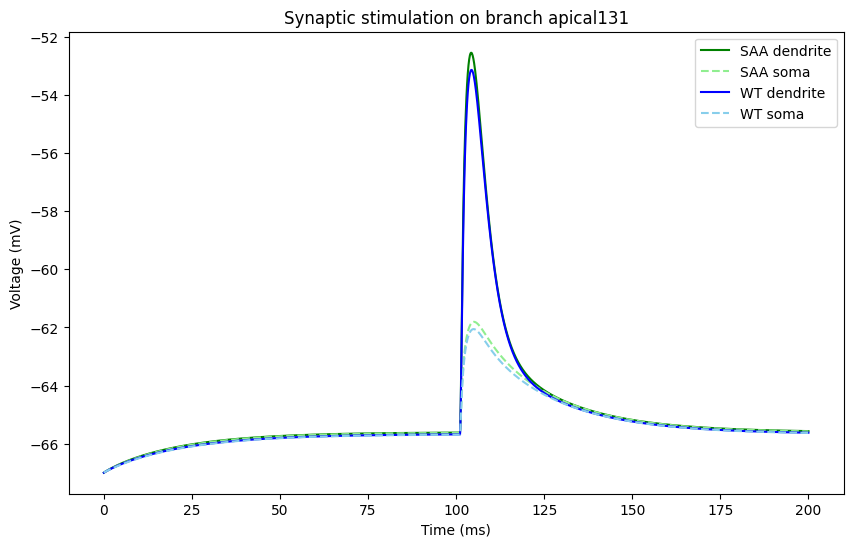

In [ ]:
from kws_excitatory_synapse import simulate_and_record, detect_spike_times

target_branch_suffix = "apical131"

sec_node_wt = find_branch_by_name(cell_wt, target_branch_suffix)
sec_node_saa = find_branch_by_name(cell_saa, target_branch_suffix)

if sec_node_wt is None:
    raise ValueError(f"WT branch ending with {target_branch_suffix} not found")
if sec_node_saa is None:
    raise ValueError(f"SAA branch ending with {target_branch_suffix} not found")

print(f"Selected WT branch: {sec_node_wt.sec.name()}, length = {sec_node_wt.sec.L:.2f} µm, spines = {len(sec_node_wt.spines)}")
print(f"Selected SAA branch: {sec_node_saa.sec.name()}, length = {sec_node_saa.sec.L:.2f} µm, spines = {len(sec_node_saa.spines)}")

# choose SAA spines
spines_saa = [s for s in sec_node_saa.spines if 'spine_head' in s.name]
print(f"Number of SAA spines with 'spine_head': {len(spines_saa)}")

# find same ones on WT
matched_wt_spines = find_matching_wt_spines(cell_wt, spines_saa, sec_node_wt.sec.name())
print(f"Number of WT spines matched to SAA: {len(matched_wt_spines)}")

# quick check
print("\nFirst 5 SAA spines:")
for s in spines_saa[:5]:
    print(f"  {s.name}, loc = {getattr(s, 'loc', 'N/A')}")
print("\nFirst 5 matched WT spines:")
for s in matched_wt_spines[:5]:
    print(f"  {s.name}, loc = {getattr(s, 'loc', 'N/A')}")

#############################

# picking the first 10 spines along the branch
n_spines = 10
saa_spines_subset = spines_saa[:n_spines]

# finding corresponding WT spines
wt_spines_subset = find_matching_wt_spines(cell_wt, saa_spines_subset, sec_node_wt.sec.name())

print(f"Synapsing on {len(saa_spines_subset)} SAA spines and {len(wt_spines_subset)} WT spines")

# run simulation for SAA and WT
t_saa, v_soma_saa, v_dend_saa, spike_count_saa = simulate_and_record(
    cell_saa, sec_node_saa, saa_spines_subset
)

t_wt, v_soma_wt, v_dend_wt, spike_count_wt = simulate_and_record(
    cell_wt, sec_node_wt, wt_spines_subset
)

print(f"SAA spike count: {spike_count_saa}, WT spike count: {spike_count_wt}")


# plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(t_saa, v_dend_saa, label="SAA dendrite", color='green')
plt.plot(t_saa, v_soma_saa, label="SAA soma", color='lightgreen', linestyle='--')
plt.plot(t_wt, v_dend_wt, label="WT dendrite", color='blue')
plt.plot(t_wt, v_soma_wt, label="WT soma", color='skyblue', linestyle='--')
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"Synaptic stimulation on branch {target_branch_suffix}")
plt.legend()
plt.show()



=== WT Spine Densities (new) ===
Basal    | Spines: 3720 | Length: 2199.1 µm | Density: 1.692 spines/µm
Trunk    | Spines:  631 | Length: 286.7 µm | Density: 2.201 spines/µm
Apical   | Spines: 5276 | Length: 2098.0 µm | Density: 2.515 spines/µm
Tuft     | Spines: 1360 | Length: 1611.6 µm | Density: 0.844 spines/µm

=== SAA Spine Densities After 25% Pruning (new) ===
Basal    | Spines: 2805 | Length: 2199.1 µm | Density: 1.276 spines/µm
Trunk    | Spines:  478 | Length: 286.7 µm | Density: 1.667 spines/µm
Apical   | Spines: 3967 | Length: 2098.0 µm | Density: 1.891 spines/µm
Tuft     | Spines: 1028 | Length: 1611.6 µm | Density: 0.638 spines/µm

=== WT Spine Densities (old) ===
Basal    | Spines: 3720 | Length: 2199.1 µm | Density: 1.692 spines/µm
Trunk    | Spines:  631 | Length: 286.7 µm | Density: 2.201 spines/µm
Apical   | Spines: 5276 | Length: 2098.0 µm | Density: 2.515 spines/µm
Tuft     | Spines: 1360 | Length: 1611.6 µm | Density: 0.844 spines/µm

=== SAA Spine Densities After

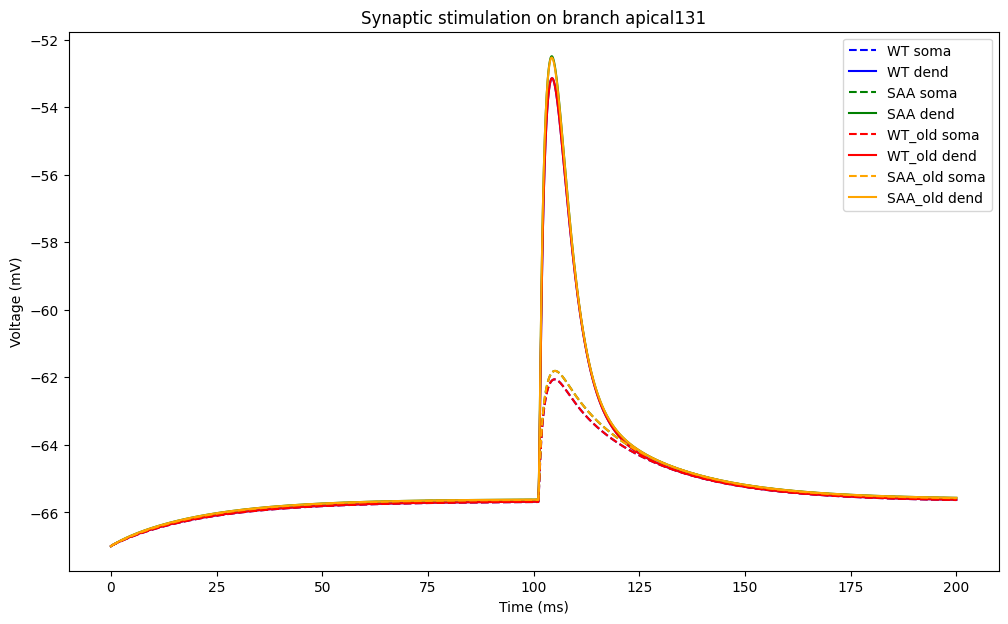

In [ ]:
import os
import matplotlib.pyplot as plt

from kws_init_cell import init_cell
from kws_init_old_cell import init_cell
from kws_spine_pruning import delete_fraction_of_spines_per_branch
from kws_pruner import find_matching_wt_spines
from kws_spines_analysis import region_density, print_summary
from kws_excitatory_synapse import simulate_and_record


os.chdir("/Users/sandek/kws/CA1Sim")  

# comparing the new and old instationatisn 
cell_wt = init_cell()
cell_saa = init_cell()
delete_fraction_of_spines_per_branch(cell_saa, fraction=0.25)

cell_wt_old = init_cell()
cell_saa_old = init_cell()
delete_fraction_of_spines_per_branch(cell_saa_old, fraction=0.25)

# choosing my favorite branch
target_branch_suffix = "apical131"

sec_node_wt      = find_branch_by_name(cell_wt, target_branch_suffix)
sec_node_saa     = find_branch_by_name(cell_saa, target_branch_suffix)
sec_node_wt_old  = find_branch_by_name(cell_wt_old, target_branch_suffix)
sec_node_saa_old = find_branch_by_name(cell_saa_old, target_branch_suffix)

for label, sec in [
    ("WT", sec_node_wt),
    ("SAA", sec_node_saa),
    ("WT_old", sec_node_wt_old),
    ("SAA_old", sec_node_saa_old),
]:
    if sec is None:
        raise ValueError(f"{label} branch ending with {target_branch_suffix} not found")
    print(f"{label}: {sec.sec.name()}, L={sec.sec.L:.2f} µm, spines={len(sec.spines)}")

# 10 SAA spines and mapping to WT
def pick_10_spines(sec_node):
    spines = [s for s in sec_node.spines if "spine_head" in s.name]
    return spines[:10]

saa_spines      = pick_10_spines(sec_node_saa)
saa_old_spines  = pick_10_spines(sec_node_saa_old)

wt_spines       = find_matching_wt_spines(cell_wt, saa_spines, sec_node_wt.sec.name())
wt_old_spines   = find_matching_wt_spines(cell_wt_old, saa_old_spines, sec_node_wt_old.sec.name())

print(f"Synapsing on {len(saa_spines)} SAA spines, {len(wt_spines)} WT spines")
print(f"Synapsing on {len(saa_old_spines)} SAA_old spines, {len(wt_old_spines)} WT_old spines")

# simulations
t_saa, v_soma_saa, v_dend_saa, spike_count_saa = simulate_and_record(cell_saa, sec_node_saa, saa_spines)
t_wt, v_soma_wt, v_dend_wt, spike_count_wt = simulate_and_record(cell_wt, sec_node_wt, wt_spines)

t_saa_old, v_soma_saa_old, v_dend_saa_old, spike_count_saa_old = simulate_and_record(cell_saa_old, sec_node_saa_old, saa_old_spines)
t_wt_old, v_soma_wt_old, v_dend_wt_old, spike_count_wt_old = simulate_and_record(cell_wt_old, sec_node_wt_old, wt_old_spines)

print(f"WT (new) spikes: {spike_count_wt}, SAA (new) spikes: {spike_count_saa}")
print(f"WT_old spikes: {spike_count_wt_old}, SAA_old spikes: {spike_count_saa_old}")

# plotting
plt.figure(figsize=(12, 7))

# new instanst
plt.plot(t_wt, v_soma_wt, label="WT soma", color="blue", linestyle="--")
plt.plot(t_wt, v_dend_wt, label="WT dend", color="blue")
plt.plot(t_saa, v_soma_saa, label="SAA soma", color="green", linestyle="--")
plt.plot(t_saa, v_dend_saa, label="SAA dend", color="green")

# old instanst
plt.plot(t_wt_old, v_soma_wt_old, label="WT_old soma", color="red", linestyle="--")
plt.plot(t_wt_old, v_dend_wt_old, label="WT_old dend", color="red")
plt.plot(t_saa_old, v_soma_saa_old, label="SAA_old soma", color="orange", linestyle="--")
plt.plot(t_saa_old, v_dend_saa_old, label="SAA_old dend", color="orange")

plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title(f"Synaptic stimulation on branch {target_branch_suffix}")
plt.legend()
plt.show()



Trial 1/1, targeting third 1

  Simulating with 5 spines
Branch <specify_cells.CA1_Pyr object at 0x12d38a200>.apical131 has 240 spines total.
Third 1 has indices 0 to 80, a total 80 spines
Deleting 26 spines out of 80 in this section.
Deleting spine at index 7
	Deleting neck section
Deleting spine at index 67
	Deleting neck section
Deleting spine at index 0
	Deleting neck section
Deleting spine at index 72
	Deleting neck section
Deleting spine at index 60
	Deleting neck section
Deleting spine at index 55
	Deleting neck section
Deleting spine at index 42
	Deleting neck section
Deleting spine at index 19
	Deleting neck section
Deleting spine at index 15
	Deleting neck section
Deleting spine at index 4
	Deleting neck section
Deleting spine at index 28
	Deleting neck section
Deleting spine at index 51
	Deleting neck section
Deleting spine at index 33
	Deleting neck section
Deleting spine at index 66
	Deleting neck section
Deleting spine at index 45
	Deleting neck section
Deleting spine at

/Users/sandek/miniforge3/envs/neuron310/lib/python3.10/site-packages/scipy/stats/_stats_py.py:6195: RuntimeWarning: invalid value encountered in scalar divide
  svar = ((n1 - 1) * v1 + (n2 - 1) * v2) / df


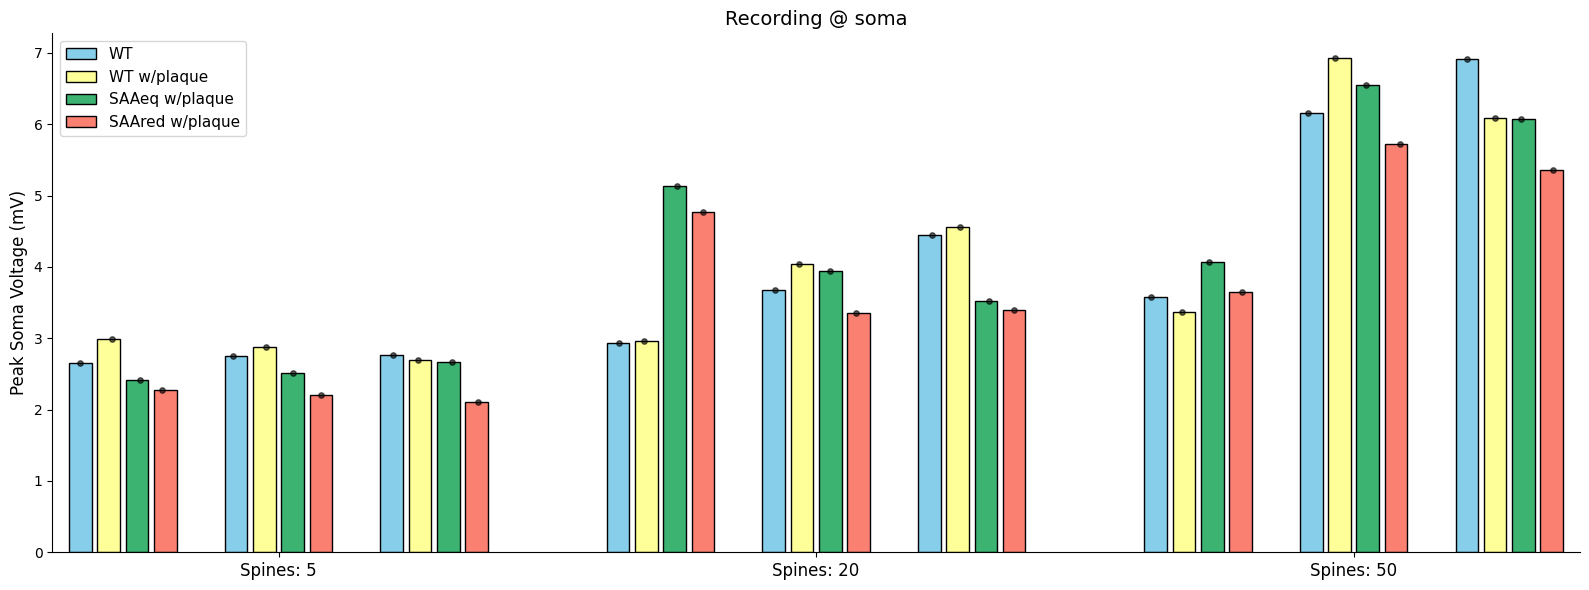

In [ ]:
### POST PROCESSING

import itertools
from scipy.stats import ttest_ind
from matplotlib.patches import Patch

def reshape_results_by_third(results, n_trials):
    reshaped = {}
    for n, data in results.items():  # each number of synapses stimulated
        reshaped[n] = {1: {}, 2: {}, 3: {}}  # separate by thirds
        for condition, values in data.items():
            thirds = {1: [], 2: [], 3: []}
            for i in range(n_trials):
                for third in (1, 2, 3):
                    index = i * 3 + (third - 1)  # correct indexing
                    thirds[third].append(values[index])
            for third in (1, 2, 3):
                reshaped[n][third][condition] = thirds[third]
    return reshaped

def plot_results(reshaped_results, spine_counts, n_trials, recording_site="soma"):
    conditions = ["WT", "plaque", "SAAeq", "SAAred"]
    thirds = [1, 2, 3]

    bar_colors = {
        "WT": "skyblue",
        "plaque": "#FFFF99",
        "SAAeq": "mediumseagreen",
        "SAAred": "salmon"
    }

    bar_vals, bar_means, bar_labels, bar_colors_list, x = [], [], [], [], []
    x_map, x_ticks, x_tick_labels = {}, [], []
    x_pos = 0
    group_spacing, spine_spacing = 1.5, 2.5

    fig, ax = plt.subplots(figsize=(16, 6))

    for spine in spine_counts:
        for third in thirds:
            for cond in conditions:
                vals = reshaped_results[spine][third][f"{cond}_{recording_site}"]
                bar_vals.append(vals)
                bar_means.append(np.mean(vals))
                bar_labels.append(f"{cond}\nT{third}")
                bar_colors_list.append(bar_colors[cond])
                x.append(x_pos)
                x_map[(spine, third, cond)] = x_pos
                x_pos += 1
            x_pos += group_spacing
        x_pos += spine_spacing

        # center tick under this spine group
        center = (x[-12] + x[-1]) / 2
        x_ticks.append(center)
        x_tick_labels.append(f"Spines: {spine}")

    # plot bars
    bars = ax.bar(x, bar_means, color=bar_colors_list, edgecolor="black")

    # raw data with jitter
    for i, vals in enumerate(bar_vals):
        jitter = np.random.normal(0, 0.1, size=len(vals))
        ax.scatter(np.full(len(vals), x[i]) + jitter, vals,
                   color="black", alpha=0.6, s=15)

    # add significance stars
    def add_star(x1, x2, y, h=0.1, text="*"):
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color="black", linewidth=1)
        ax.text((x1 + x2)/2, y + h + 0.01, text, ha="center", va="bottom", fontsize=10)

    # intra-condition tests (between thirds)
    for spine in spine_counts:
        for cond in conditions:
            for (t1, t2) in [(1, 2), (1, 3), (2, 3)]:
                vals1 = reshaped_results[spine][t1][f"{cond}_{recording_site}"]
                vals2 = reshaped_results[spine][t2][f"{cond}_{recording_site}"]
                stat, p = ttest_ind(vals1, vals2)
                if p < 0.05:
                    x1 = x_map[(spine, t1, cond)]
                    x2 = x_map[(spine, t2, cond)]
                    y = max(max(vals1), max(vals2)) + 0.2
                    add_star(x1, x2, y)

    # cross-condition tests (within same third)
    for spine in spine_counts:
        for third in thirds:
            for (c1, c2) in itertools.combinations(conditions, 2):
                vals1 = reshaped_results[spine][third][f"{c1}_{recording_site}"]
                vals2 = reshaped_results[spine][third][f"{c2}_{recording_site}"]
                stat, p = ttest_ind(vals1, vals2)
                if p < 0.05:
                    x1 = x_map[(spine, third, c1)]
                    x2 = x_map[(spine, third, c2)]
                    y = max(max(vals1), max(vals2)) + 0.4
                    add_star(x1, x2, y)

    # formatting
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_tick_labels, fontsize=12)
    ax.set_ylabel(f"Peak {recording_site.capitalize()} Voltage (mV)", fontsize=12)
    ax.set_title(f"Recording @ {recording_site}", fontsize=14)
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_xlim(min(x)-1, max(x)+1)

    legend_elements = [
        Patch(facecolor="skyblue", edgecolor="black", label="WT"),
        Patch(facecolor="#FFFF99", edgecolor="black", label="WT w/plaque"),
        Patch(facecolor="mediumseagreen", edgecolor="black", label="SAAeq w/plaque"),
        Patch(facecolor="salmon", edgecolor="black", label="SAAred w/plaque")
    ]
    ax.legend(handles=legend_elements, fontsize=11, title_fontsize=12, loc="upper left")
    plt.tight_layout()
    plt.show()

# run reshaping + plotting
reshaped_results = reshape_results_by_third(results_dict, n_trials=n_trials)
plot_results(reshaped_results, spine_counts=[5, 20, 50], n_trials=n_trials, recording_site="soma")
